# Stage 1 — XGBoost (Barrier Prediction)

This notebook trains XGBoost models for Stage 1 barrier prediction using NFHS-5 district-level data.

It predicts three proxy-based barriers (low utilisation = high barrier):
- Household
- Logistic
- Facility


## 1. Imports

In [10]:
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\major project\BarrierLens_MP_G25_P48


## 2. Load Preprocessed Data

In [11]:
processed_dir = PROJECT_ROOT / "data" / "processed"

X = pd.read_csv(processed_dir / "X_features.csv")
y_household = pd.read_csv(processed_dir / "y_household.csv").squeeze("columns")
y_logistic = pd.read_csv(processed_dir / "y_logistic.csv").squeeze("columns")
y_facility = pd.read_csv(processed_dir / "y_facility.csv").squeeze("columns")

print("X shape:", X.shape)
print("y_household shape:", y_household.shape)
print("y_logistic shape:", y_logistic.shape)
print("y_facility shape:", y_facility.shape)

print("\nTarget distributions:")
print("household:\n", y_household.value_counts(normalize=True).sort_index())
print("\nlogistic:\n", y_logistic.value_counts(normalize=True).sort_index())
print("\nfacility:\n", y_facility.value_counts(normalize=True).sort_index())

X shape: (706, 54)
y_household shape: (706,)
y_logistic shape: (706,)
y_facility shape: (706,)

Target distributions:
household:
 target_household
0    0.5
1    0.5
Name: proportion, dtype: float64

logistic:
 target_logistic
0    0.5
1    0.5
Name: proportion, dtype: float64

facility:
 target_facility
0    0.5
1    0.5
Name: proportion, dtype: float64


## 3. Train-Test Split + Scaling

In [12]:
from src.preprocessing.split_scale import split_and_scale

feature_names = X.columns.tolist()

data_household = pd.concat([X, y_household.rename("target_household")], axis=1)
data_logistic = pd.concat([X, y_logistic.rename("target_logistic")], axis=1)
data_facility = pd.concat([X, y_facility.rename("target_facility")], axis=1)

X_train_hh, X_test_hh, y_train_hh, y_test_hh, scaler_hh = split_and_scale(data_household, "target_household", apply_scaling=True)
X_train_log, X_test_log, y_train_log, y_test_log, scaler_log = split_and_scale(data_logistic, "target_logistic", apply_scaling=True)
X_train_fac, X_test_fac, y_train_fac, y_test_fac, scaler_fac = split_and_scale(data_facility, "target_facility", apply_scaling=True)

target_household - Train: 564 rows | Test: 142 rows
target_logistic - Train: 564 rows | Test: 142 rows
target_facility - Train: 564 rows | Test: 142 rows


## Model Training Overview

Three separate XGBoost models are trained in this notebook.

Each model predicts one independent binary classification target from the Stage 1 pipeline:
- `target_household`
- `target_logistic`
- `target_facility`

This preserves the Stage 1 setup where each barrier is modeled as its own supervised learning task.

## 4. Train XGBoost Model Function

In [13]:
from src.models.xgboost_model import train_xgboost

xgb_hh, shap_hh = train_xgboost(X_train_hh, y_train_hh, X_test_hh, feature_names, "household")
xgb_log, shap_log = train_xgboost(X_train_log, y_train_log, X_test_log, feature_names, "logistic")
xgb_fac, shap_fac = train_xgboost(X_train_fac, y_train_fac, X_test_fac, feature_names, "facility")

c:\Users\sharmila\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:05:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params for household: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'reg_alpha': 0.1}


c:\Users\sharmila\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:05:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params for logistic: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.1}


c:\Users\sharmila\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:05:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params for facility: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.0}


## 5. Model Evaluation

In [14]:
from src.evaluation.metrics import evaluate_model

results = []
results.append(evaluate_model(xgb_hh, X_test_hh, y_test_hh, "XGBoost", "Household Barrier"))
results.append(evaluate_model(xgb_log, X_test_log, y_test_log, "XGBoost", "Logistic Barrier"))
results.append(evaluate_model(xgb_fac, X_test_fac, y_test_fac, "XGBoost", "Facility Barrier"))

xgb_results_df = pd.DataFrame(results)
print("\nXGBoost evaluation summary:")
display(xgb_results_df[["Model", "Target", "Accuracy", "ROC-AUC", "Precision", "Recall", "F1-Score"]])


=== XGBoost | Household Barrier barrier ===
  Model       : XGBoost
  Target      : Household Barrier
  Accuracy    : 0.8944
  ROC-AUC     : 0.9562
  Precision   : 0.85
  Recall      : 0.9577
  F1-Score    : 0.9007
              precision    recall  f1-score   support

           0       0.95      0.83      0.89        71
           1       0.85      0.96      0.90        71

    accuracy                           0.89       142
   macro avg       0.90      0.89      0.89       142
weighted avg       0.90      0.89      0.89       142


=== XGBoost | Logistic Barrier barrier ===
  Model       : XGBoost
  Target      : Logistic Barrier
  Accuracy    : 0.7958
  ROC-AUC     : 0.8826
  Precision   : 0.7763
  Recall      : 0.831
  F1-Score    : 0.8027
              precision    recall  f1-score   support

           0       0.82      0.76      0.79        71
           1       0.78      0.83      0.80        71

    accuracy                           0.80       142
   macro avg       0.80 

,Model,Target,Accuracy,ROC-AUC,Precision,Recall,F1-Score
0,XGBoost,Household Barrier,0.8944,0.9562,0.8500,0.9577,0.9007
1,XGBoost,Logistic Barrier,0.7958,0.8826,0.7763,0.8310,0.8027
2,XGBoost,Facility Barrier,0.7465,0.8445,0.7465,0.7465,0.7465


## 6. Cross Validation

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_cv = X.values

cv_hh = cross_val_score(xgb_hh, X_cv, y_household, cv=cv, scoring="roc_auc", n_jobs=-1)
cv_log = cross_val_score(xgb_log, X_cv, y_logistic, cv=cv, scoring="roc_auc", n_jobs=-1)
cv_fac = cross_val_score(xgb_fac, X_cv, y_facility, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"XGB | household | CV AUC {cv_hh.mean():.4f} +/- {cv_hh.std():.4f}")
print(f"XGB | logistic  | CV AUC {cv_log.mean():.4f} +/- {cv_log.std():.4f}")
print(f"XGB | facility  | CV AUC {cv_fac.mean():.4f} +/- {cv_fac.std():.4f}")

XGB | household | CV AUC 0.9511 +/- 0.0070
XGB | logistic  | CV AUC 0.9170 +/- 0.0176
XGB | facility  | CV AUC 0.8717 +/- 0.0413


## 7. SHAP Analysis

SHAP summary plot - household


c:\Users\sharmila\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


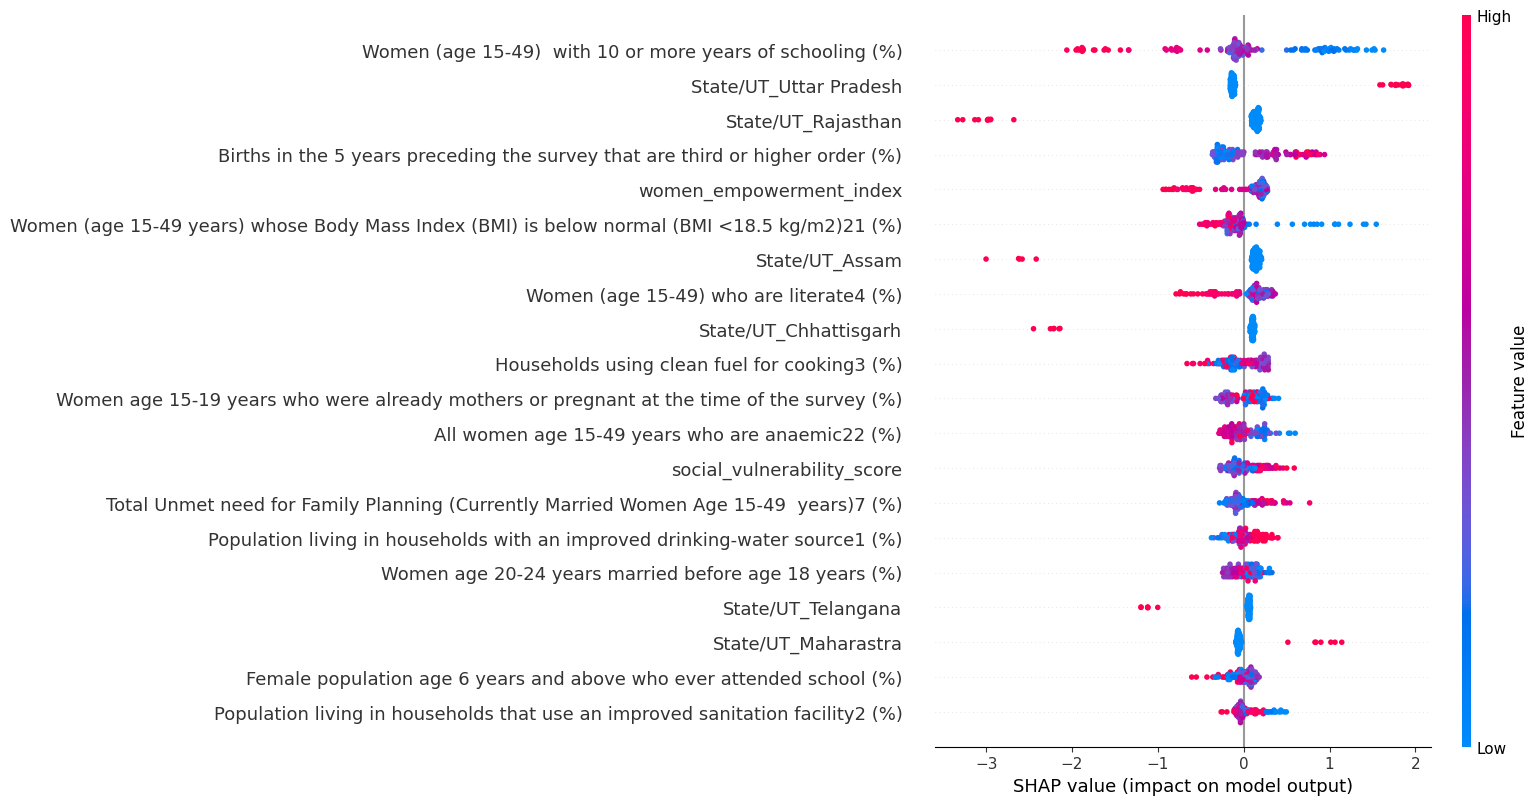

SHAP bar plot - household


c:\Users\sharmila\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


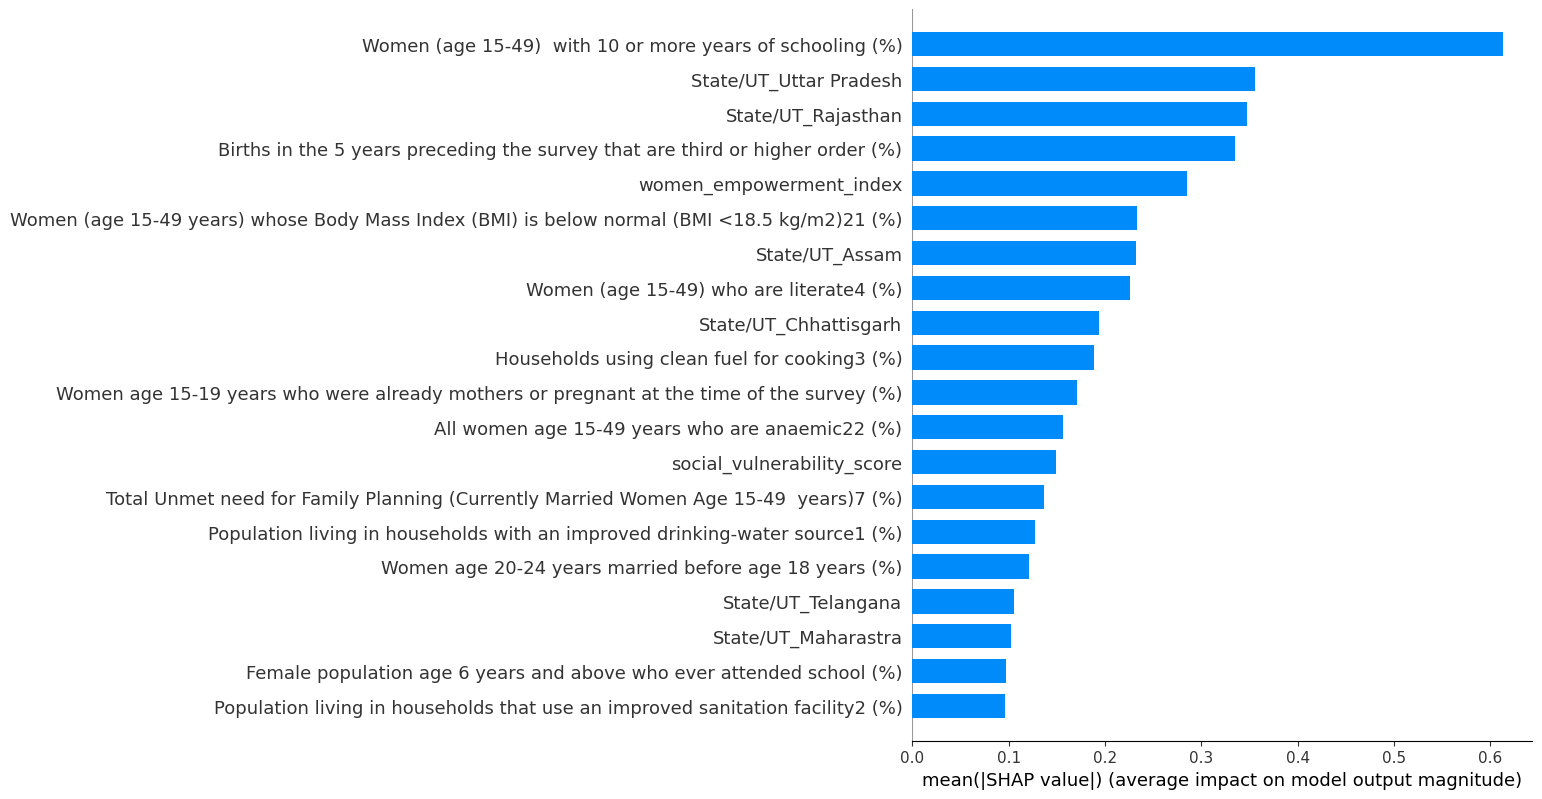

SHAP summary plot - logistic


c:\Users\sharmila\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


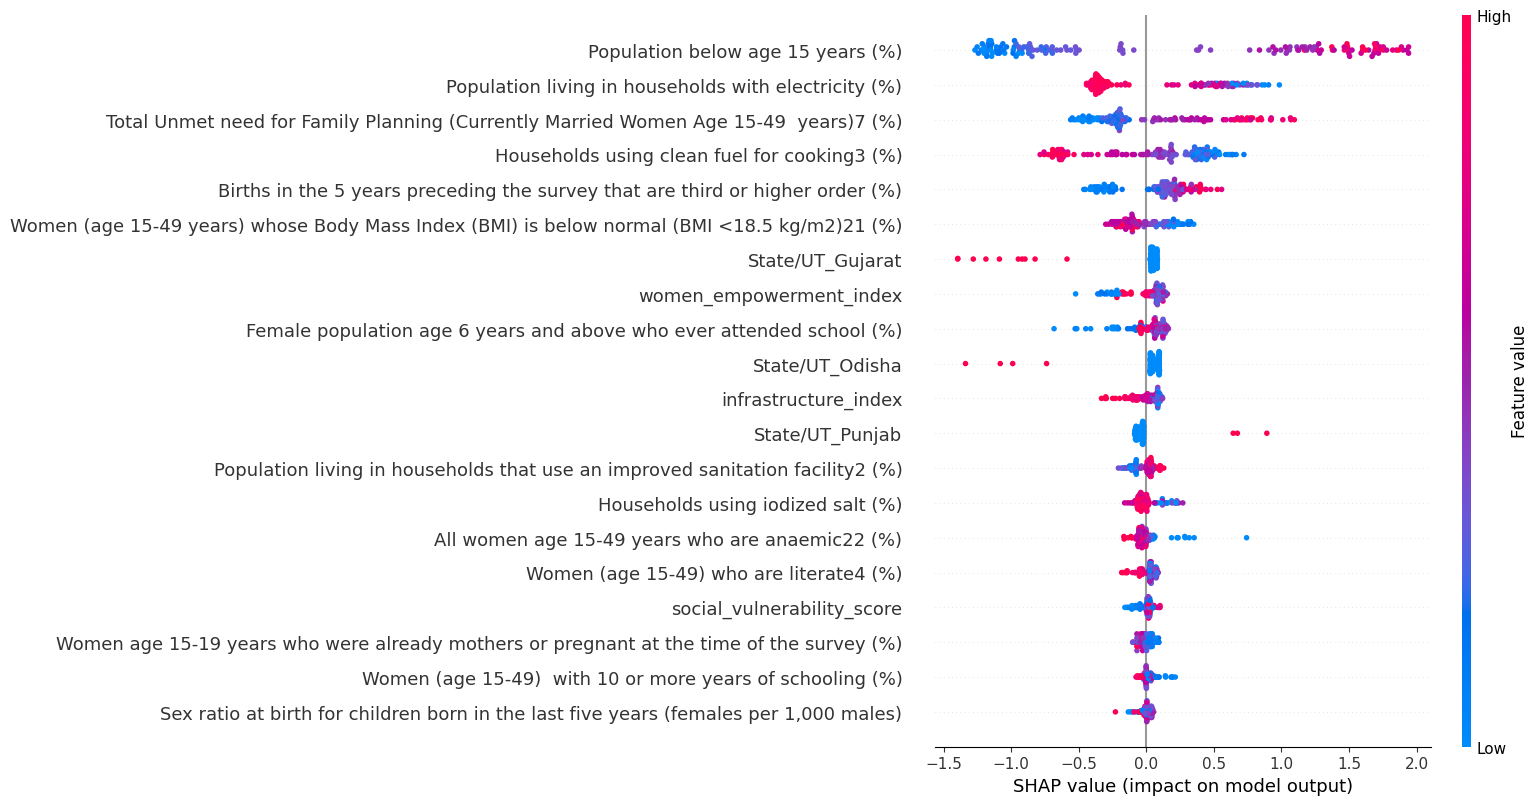

SHAP bar plot - logistic


c:\Users\sharmila\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


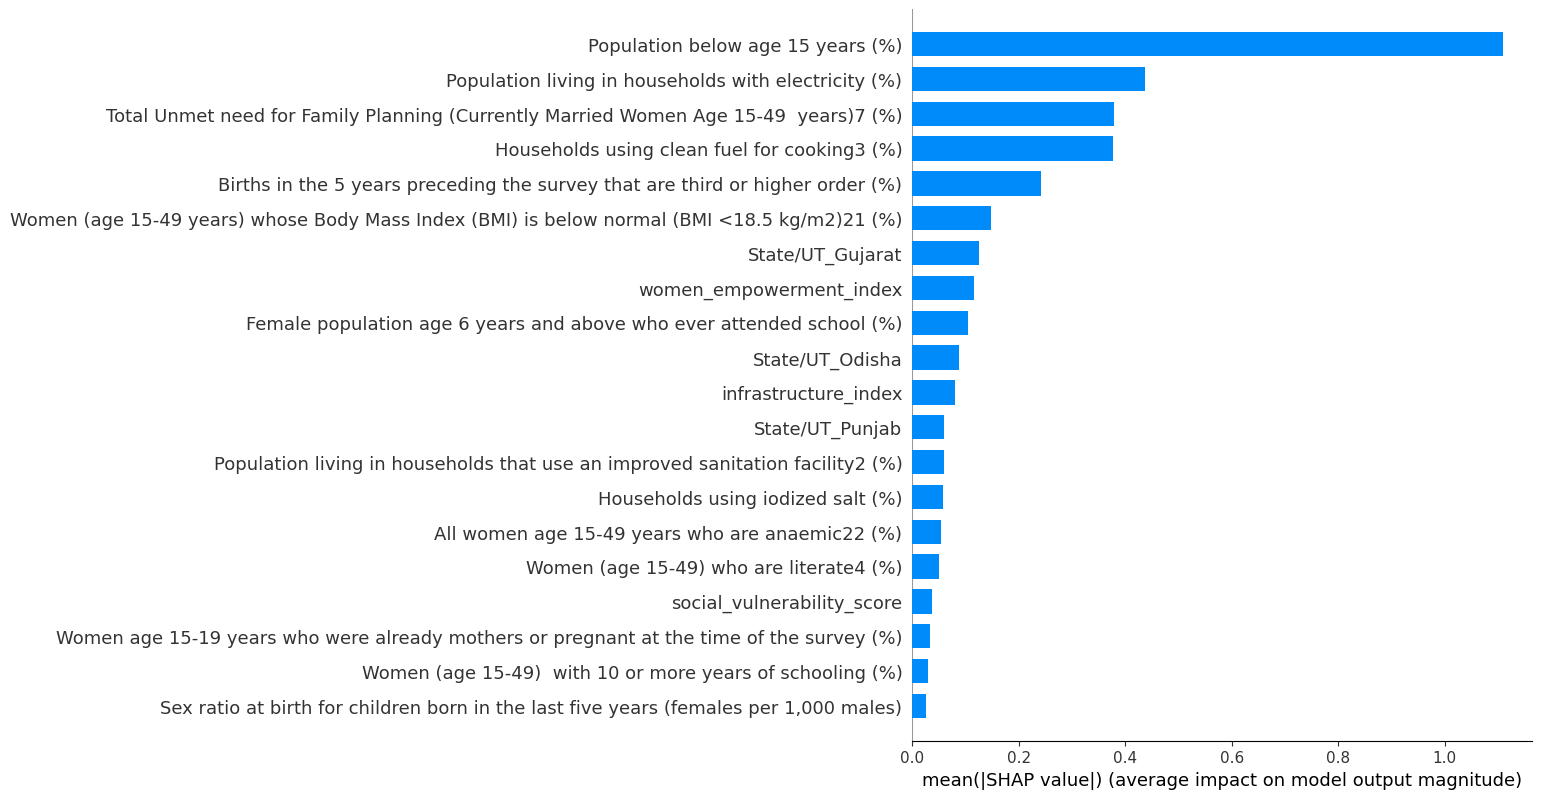

SHAP summary plot - facility


c:\Users\sharmila\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


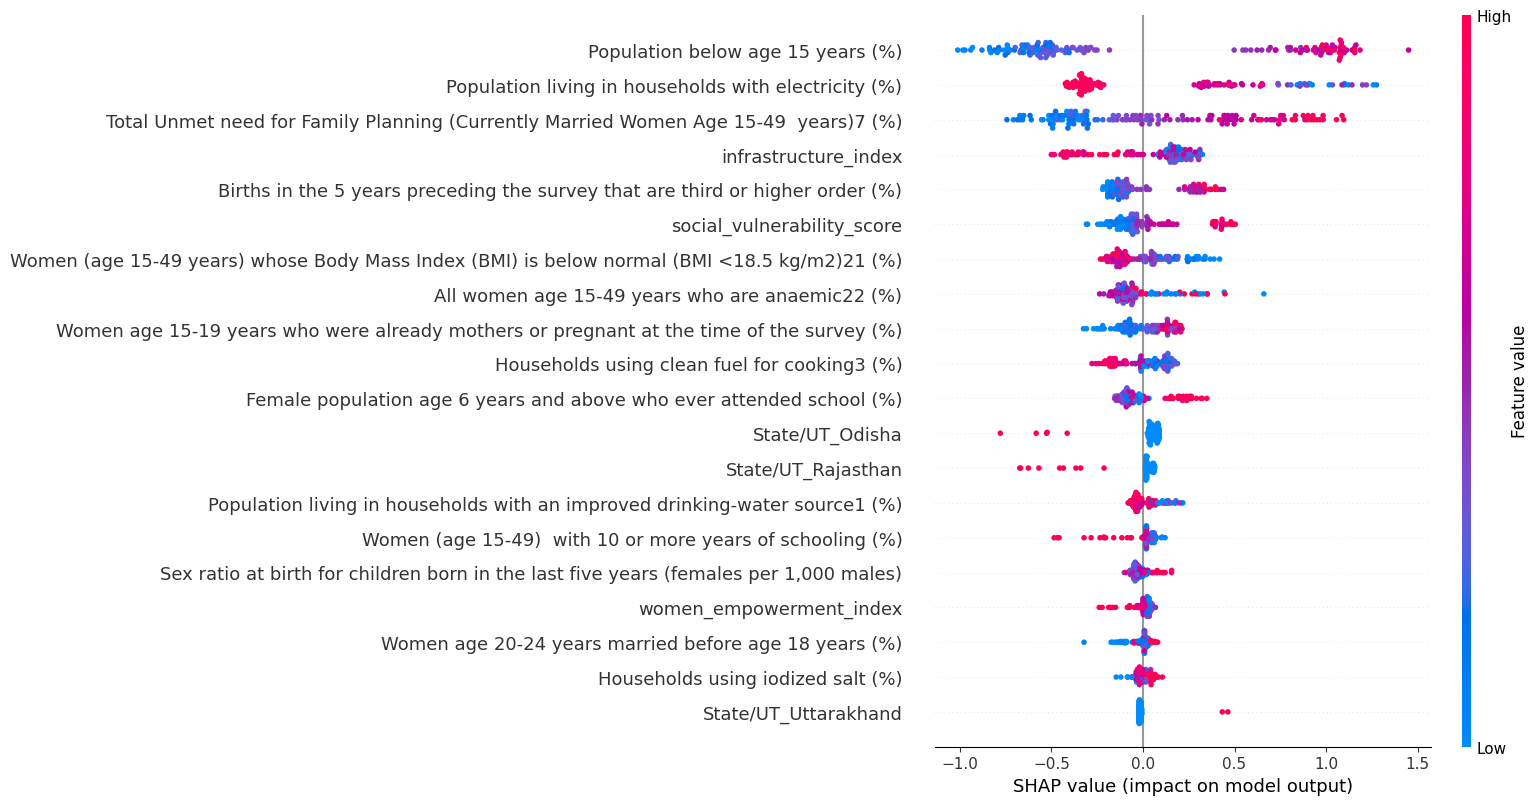

SHAP bar plot - facility


c:\Users\sharmila\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


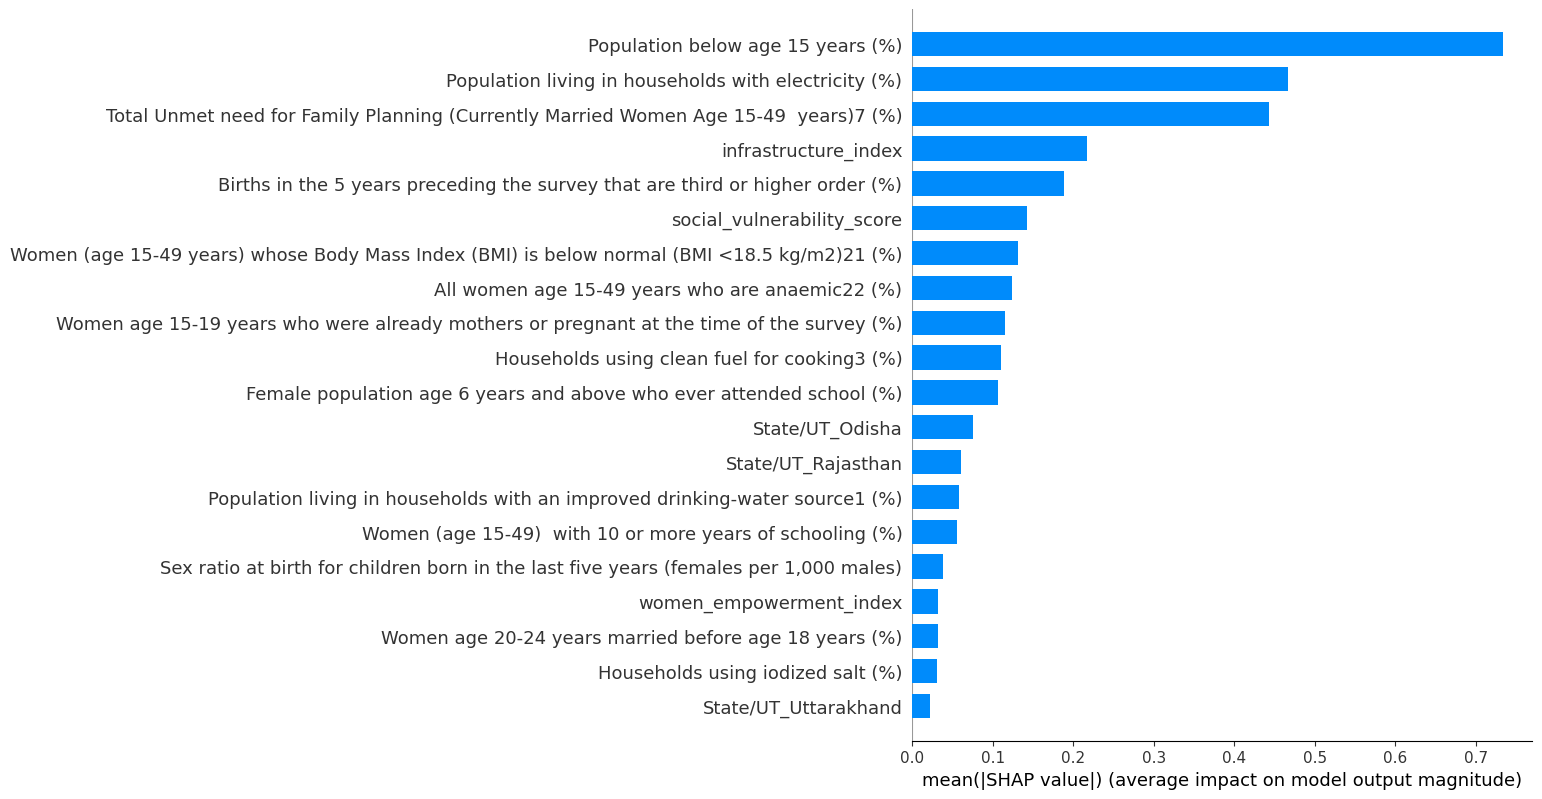

In [16]:
shap_payload = {
    "household": (shap_hh, X_test_hh),
    "logistic": (shap_log, X_test_log),
    "facility": (shap_fac, X_test_fac),
}

for target_name, (shap_values, X_test_target) in shap_payload.items():
    X_test_df = pd.DataFrame(X_test_target, columns=feature_names)

    print(f"SHAP summary plot - {target_name}")
    shap.summary_plot(shap_values, X_test_df)

    print(f"SHAP bar plot - {target_name}")
    shap.summary_plot(shap_values, X_test_df, plot_type="bar")

## 8. Save Models (Optional Check)

In [17]:
save_dir = PROJECT_ROOT / "saved_models" / "stage1"
print("Saved XGBoost files:")
for p in sorted(save_dir.glob("xgboost_*.pkl")):
    print("-", p.name)

xgb_household_loaded = joblib.load(save_dir / "xgboost_household.pkl")
xgb_logistic_loaded = joblib.load(save_dir / "xgboost_logistic.pkl")
xgb_facility_loaded = joblib.load(save_dir / "xgboost_facility.pkl")
print("\nReload check complete.")

Saved XGBoost files:
- xgboost_facility.pkl
- xgboost_household.pkl
- xgboost_logistic.pkl

Reload check complete.


## Model Performance Validation

Model performance is validated using ROC-AUC with 5-fold stratified cross-validation.

The main quality check is the cross-validation ROC-AUC mean +/- standard deviation for each target model.
Expected performance range for this Stage 1 XGBoost setup is approximately ROC-AUC ~ 0.88-0.90.

In [18]:
cv_validation_df = pd.DataFrame(
    {
        "Target": ["Household Barrier", "Logistic Barrier", "Facility Barrier"],
        "CV ROC-AUC Mean": [cv_hh.mean(), cv_log.mean(), cv_fac.mean()],
        "CV ROC-AUC Std": [cv_hh.std(), cv_log.std(), cv_fac.std()],
    }
)

display(cv_validation_df)

print("Model Performance Validation (ROC-AUC, 5-fold CV):")
for _, row in cv_validation_df.iterrows():
    print(
        f"{row['Target']}: {row['CV ROC-AUC Mean']:.4f} +/- {row['CV ROC-AUC Std']:.4f}"
    )

print("\nExpected performance guide: ROC-AUC ~ 0.88-0.90")

,Target,CV ROC-AUC Mean,CV ROC-AUC Std
0,Household Barrier,0.951057,0.007038
1,Logistic Barrier,0.917029,0.017558
2,Facility Barrier,0.871676,0.041265


Model Performance Validation (ROC-AUC, 5-fold CV):
Household Barrier: 0.9511 +/- 0.0070
Logistic Barrier: 0.9170 +/- 0.0176
Facility Barrier: 0.8717 +/- 0.0413

Expected performance guide: ROC-AUC ~ 0.88-0.90
